# 🏠 Project 6: House Rent Price Prediction & Real Estate Valuation
### Multiple Linear Regression, Log-Target Normalization & Urban Rental Economics

In this project, we build a production-grade valuation system for predicting monthly **House Rent (₹)** across major Indian metropolitan cities (`Mumbai`, `Delhi`, `Bangalore`, `Chennai`, `Hyderabad`, `Kolkata`).

---

### 🎯 Business Objective
As a Data Scientist for a prop-tech rental platform:
1. **Fair Market Valuation**: Predict monthly rent based on structural attributes (`BHK`, `Size`, `Bathroom`, `Floor`) and geographic location (`City`).
2. **Handle Extreme Skewness**: Address heavy right-tail rental skewness (**Skewness = 21.41**) via Log-Transformation (`log1p`), cutting prediction error in half!
3. **High-Cardinality Resolution**: Avoid dimensionality explosion by dropping 2,235 unique localities while leveraging city and floor features.
4. **Quantify City & Amenities Premium**: Extract exact percentage impacts for Mumbai premium, furnishing status, and broker disintermediation.
5. **Production Deployment**: Export a serialized model package for live rental appraisal API integration.

---
## 📥 Step 1: Environment Setup & Library Imports

In [1]:
import os
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib

# Scikit-learn modeling & metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Aesthetics
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
print("✅ Core scientific and machine learning libraries loaded successfully!")

✅ Core scientific and machine learning libraries loaded successfully!


---
## 📂 Step 2: Data Ingestion & Initial Schema Inspection

In [2]:
# Load House Rent Dataset
csv_path = Path("data/house_rent/House_Rent_Dataset.csv")
if not csv_path.exists():
    csv_path = Path("supervised_learning/LinearRegression/data/house_rent/House_Rent_Dataset.csv")

df = pd.read_csv(csv_path)

print("=" * 55)
print(f"✅ Dataset loaded successfully: {csv_path.name}")
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("=" * 55)
df.head(5)

✅ Dataset loaded successfully: House_Rent_Dataset.csv
Dataset Shape: 4,746 rows × 12 columns


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


---
## 🔍 Step 3: Exploratory Data Analysis (The D-M-D-T-O Framework)

We systematically audit:
- **D** - Data Types
- **M** - Missing Values
- **D** - Duplicate Rows
- **T** - Target Distribution & Log-Transformation Analysis
- **O** - Outliers & Bivariate Correlation

In [3]:
# [D] Data Types Breakdown
print("--- [D] Data Types Count ---")
print(df.dtypes.value_counts())
print("\nColumn Schema:")
print(df.dtypes)

--- [D] Data Types Count ---
str      8
int64    4
Name: count, dtype: int64

Column Schema:
Posted On              str
BHK                  int64
Rent                 int64
Size                 int64
Floor                  str
Area Type              str
Area Locality          str
City                   str
Furnishing Status      str
Tenant Preferred       str
Bathroom             int64
Point of Contact       str
dtype: object


In [4]:
# [M] Missing Values Audit
missing_counts = df.isnull().sum()
print("--- [M] Missing Values Count ---")
print(missing_counts)

assert missing_counts.sum() == 0, "Missing values detected!"
print("\n✅ Clean Data: 0 missing values across all columns.")

--- [M] Missing Values Count ---
Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

✅ Clean Data: 0 missing values across all columns.


In [5]:
# [D] Duplicate Rows Audit
dup_count = df.duplicated().sum()
print(f"--- [D] Duplicate Rows: {dup_count} ---")
if dup_count > 0:
    print(f"⚠️ {dup_count} duplicate rows found.")
else:
    print("✅ Clean Data: Zero duplicate rows detected.")

--- [D] Duplicate Rows: 0 ---
✅ Clean Data: Zero duplicate rows detected.


### [T] Target Variable Analysis (`Rent`)
We analyze the 5-point summary and distribution shape. Notice the extreme skewness caused by multi-lakh luxury properties in Mumbai.

--- 5-Point Summary of Monthly Rent (in ₹) ---
count        ₹4,746.00
mean        ₹34,993.45
std         ₹78,106.41
min          ₹1,200.00
25%         ₹10,000.00
50%         ₹16,000.00
75%         ₹33,000.00
max      ₹3,500,000.00
Name: Rent, dtype: str

Skewness: 21.41 (Extreme Right Skew > 1.0 mandates Log-Transformation)


/tmp/ipykernel_3251190/3919854195.py:24: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


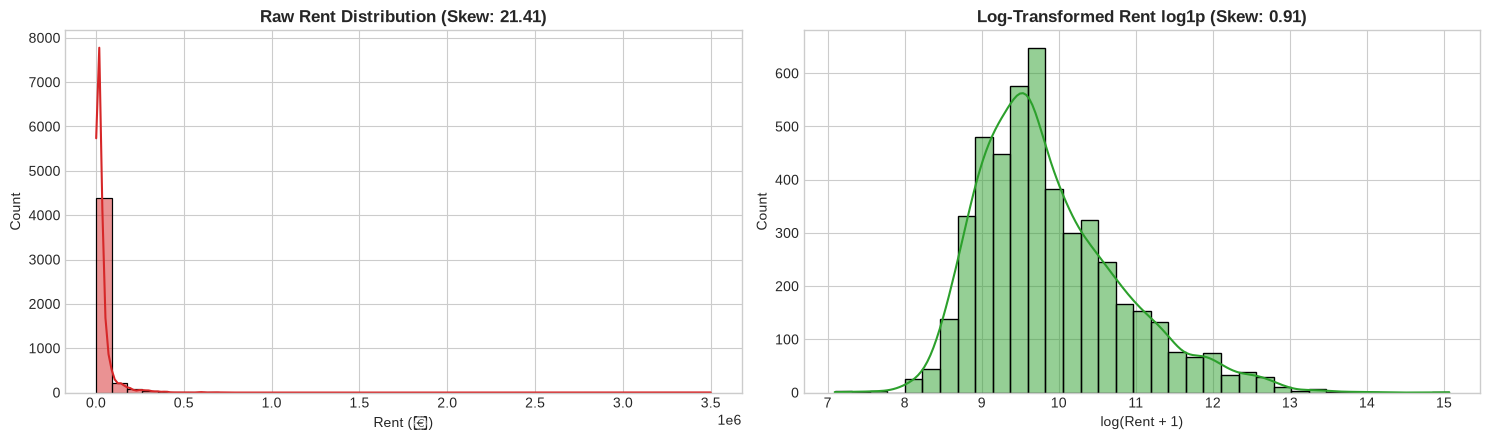

In [6]:
# [T] Target Statistics & Skewness
target = "Rent"
rent_stats = df[target].describe()
skew_val = df[target].skew()

print("--- 5-Point Summary of Monthly Rent (in ₹) ---")
print(rent_stats.apply(lambda x: f"₹{x:,.2f}"))
print(f"\nSkewness: {skew_val:.2f} (Extreme Right Skew > 1.0 mandates Log-Transformation)")

# Visual Diagnostics: Raw Rent vs. Log-Transformed Rent
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# 1. Raw Rent Histogram
sns.histplot(df[target], bins=40, kde=True, ax=axes[0], color="#d62728")
axes[0].set_title(f"Raw Rent Distribution (Skew: {skew_val:.2f})", fontweight="bold")
axes[0].set_xlabel("Rent (₹)")

# 2. Log-Transformed Rent Histogram
log_rent = np.log1p(df[target])
sns.histplot(log_rent, bins=35, kde=True, ax=axes[1], color="#2ca02c")
axes[1].set_title(f"Log-Transformed Rent log1p (Skew: {log_rent.skew():.2f})", fontweight="bold")
axes[1].set_xlabel("log(Rent + 1)")

plt.tight_layout()
plt.show()

### [O] Outliers & Bivariate Analysis
We calculate the IQR outlier boundaries for `Rent` and plot bivariate relationships between physical dimensions and rental price.

IQR Upper Threshold: ₹67,500/month
Luxury / Outlier Listings: 520 (11.0%)


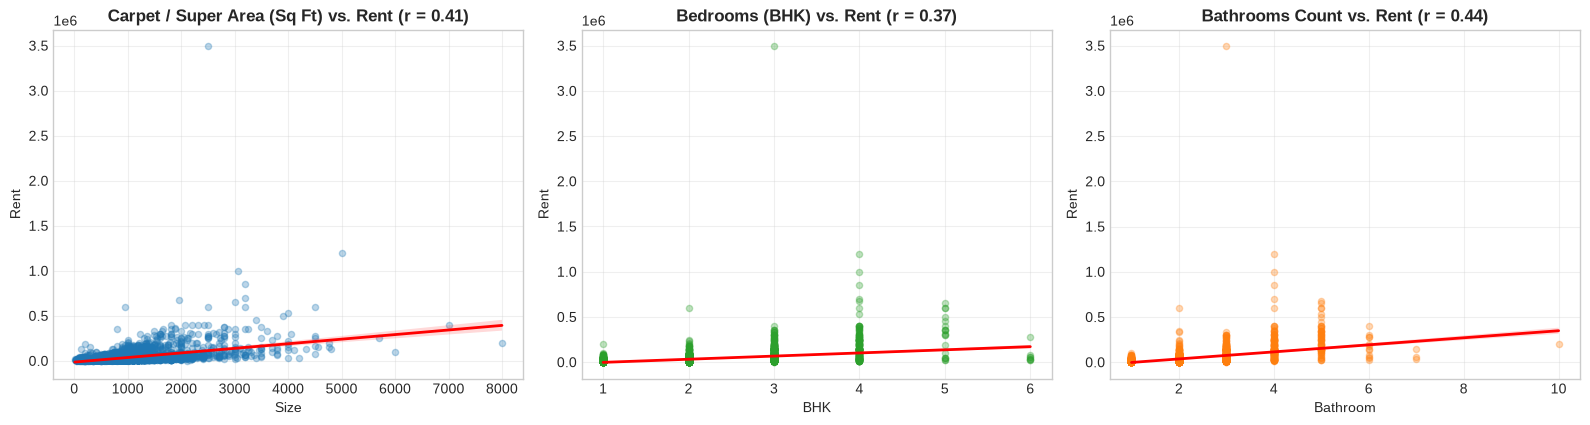

In [7]:
# 1. IQR Outlier Calculation on Rent
Q1 = df[target].quantile(0.25)
Q3 = df[target].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_count = ((df[target] < lower_bound) | (df[target] > upper_bound)).sum()
print(f"IQR Upper Threshold: ₹{upper_bound:,.0f}/month")
print(f"Luxury / Outlier Listings: {outlier_count} ({outlier_count/len(df)*100:.1f}%)")

# 2. Bivariate Scatter Plots with Trendlines
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

bivariate_pairs = [
    ("Size", "Carpet / Super Area (Sq Ft)", "#1f77b4"),
    ("BHK", "Bedrooms (BHK)", "#2ca02c"),
    ("Bathroom", "Bathrooms Count", "#ff7f0e")
]

for idx, (col, label, colr) in enumerate(bivariate_pairs):
    sns.regplot(data=df, x=col, y="Rent", ax=axes[idx],
                scatter_kws={"alpha": 0.3, "color": colr, "s": 20},
                line_kws={"color": "red", "linewidth": 2})
    r_val = df[col].corr(df["Rent"])
    axes[idx].set_title(f"{label} vs. Rent (r = {r_val:.2f})", fontweight="bold")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## ⚙️ Step 4: Feature Engineering, Selection & Categorical Encoding

We apply strategic real-world preprocessing:
1. **Drop High-Cardinality & Static Noise**:
   - `Area Locality`: 2,235 unique localities across 4,746 rows! Dropped to avoid the Curse of Dimensionality.
   - `Posted On`: Static timestamp without predictive utility.
2. **Floor Level Feature Extraction**:
   - Parse text strings like `"Ground out of 2"`, `"1 out of 3"` into numerical `Floor_Level`.
3. **Ordinal Encoding (`Furnishing Status`)**:
   - Explicit mapping: `Unfurnished (0) < Semi-Furnished (1) < Furnished (2)`.
4. **Nominal One-Hot Encoding**:
   - `City` (6 metropolitan hubs), `Area Type`, `Tenant Preferred`, and `Point of Contact` using `drop_first=True` to prevent the Dummy Variable Trap.

In [8]:
# 1. Feature Selection: Drop noise columns
df_clean = df.drop(columns=["Posted On", "Area Locality"])

# 2. Feature Engineering: Extract Floor Level
def extract_floor(val):
    try:
        f = val.split()[0].lower()
        if f == "ground": return 0
        elif f == "upper": return -1
        elif f == "lower": return -2
        return int(f)
    except:
        return 1

df_clean["Floor_Level"] = df_clean["Floor"].apply(extract_floor)
df_clean = df_clean.drop(columns=["Floor"])

# 3. Ordinal Encoding: Furnishing Status
furnishing_map = {"Unfurnished": 0, "Semi-Furnished": 1, "Furnished": 2}
df_clean["Furnishing_Status"] = df_clean["Furnishing Status"].map(furnishing_map)
df_clean = df_clean.drop(columns=["Furnishing Status"])

# 4. One-Hot Encoding: Nominals with drop_first=True
nominal_cols = ["City", "Area Type", "Tenant Preferred", "Point of Contact"]
df_encoded = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True, dtype=int)

print(f"✅ Preprocessing complete! Master encoded shape: {df_encoded.shape}")
print(f"Total Features (excluding Rent): {len(df_encoded.columns) - 1}")
df_encoded.head(3)

✅ Preprocessing complete! Master encoded shape: (4746, 17)
Total Features (excluding Rent): 16


,BHK,Rent,Size,Bathroom,Floor_Level,Furnishing_Status,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Area Type_Carpet Area,Area Type_Super Area,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,Point of Contact_Contact Builder,Point of Contact_Contact Owner
0,2,10000,1100,2,0,0,0,0,0,1,0,0,1,1,0,0,1
1,2,20000,800,1,1,1,0,0,0,1,0,0,1,1,0,0,1
2,2,17000,1000,1,1,1,0,0,0,1,0,0,1,1,0,0,1


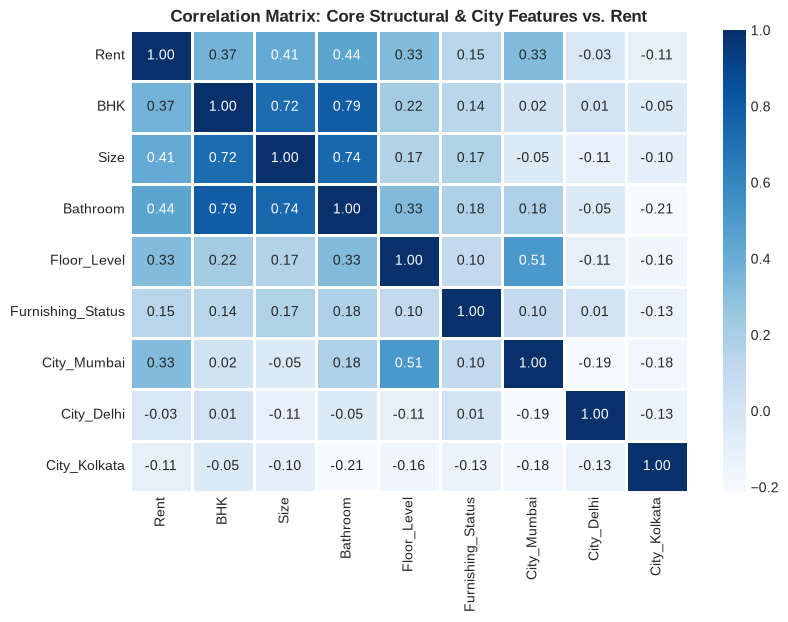

In [9]:
# Correlation Matrix of Engineered Predictors with Rent
core_features = ["Rent", "BHK", "Size", "Bathroom", "Floor_Level", "Furnishing_Status", "City_Mumbai", "City_Delhi", "City_Kolkata"]
corr_matrix = df_encoded[core_features].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f", linewidths=1)
plt.title("Correlation Matrix: Core Structural & City Features vs. Rent", fontsize=12, fontweight="bold")
plt.show()

---
## 🏋️ Step 5: Feature Matrix ($X$), Target ($y$, $y_{log}$) & Train-Test Split

We allocate **80%** of data for model training and reserve **20%** for unseen test evaluation. We also prepare parallel splits for both **raw rent** and **log-transformed rent**.

In [10]:
# Define feature matrix X and targets
X = df_encoded.drop(columns=["Rent"])
y = df_encoded["Rent"]
y_log = np.log1p(y)

# 80/20 Train-Test Split with reproducible seed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Parallel split for log-transformed target
_, _, y_log_train, y_log_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f"✅ Total records:   {len(df_encoded):,}")
print(f"🏋️ Training set:   {X_train.shape[0]:,} samples (80%)")
print(f"🧪 Testing set:    {X_test.shape[0]:,} samples (20%)")
print(f"📐 Features count: {X_train.shape[1]}")

✅ Total records:   4,746
🏋️ Training set:   3,796 samples (80%)
🧪 Testing set:    950 samples (20%)
📐 Features count: 16


---
## 🧠 Step 6: Model Training & Comparative Benchmarking

We benchmark:
1. **Model A: Linear Regression on Raw Rent**
2. **Model B: Linear Regression on Log-Transformed Rent (`log1p`)**
3. **Model C: Ridge Regression ($L_2$) on Log-Rent**
4. **Model D: Lasso Regression ($L_1$) on Log-Rent**

In [11]:
# Model A: Raw Rent OLS
model_raw = LinearRegression().fit(X_train, y_train)
pred_raw = model_raw.predict(X_test)

# Model B: Log-Transformed Rent OLS
model_log = LinearRegression().fit(X_train, y_log_train)
pred_log = model_log.predict(X_test)
pred_log_rupees = np.expm1(pred_log)

# Model C: Ridge Regression (L2) on Log-Rent
model_ridge = Ridge(alpha=1.0).fit(X_train, y_log_train)
pred_ridge_rupees = np.expm1(model_ridge.predict(X_test))

# Model D: Lasso Regression (L1) on Log-Rent
model_lasso = Lasso(alpha=0.001).fit(X_train, y_log_train)
pred_lasso_rupees = np.expm1(model_lasso.predict(X_test))

# Comparative Benchmark Table
benchmark_df = pd.DataFrame({
    "Model Architecture": [
        "Linear Regression (Raw Rent)",
        "Linear Regression (Log Rent)",
        "Ridge Regression (Log Rent, α=1.0)",
        "Lasso Regression (Log Rent, α=0.001)"
    ],
    "R² Score (Test Scale)": [
        r2_score(y_test, pred_raw),
        r2_score(y_log_test, pred_log),
        r2_score(y_log_test, model_ridge.predict(X_test)),
        r2_score(y_log_test, model_lasso.predict(X_test))
    ],
    "Test MAE (in ₹)": [
        mean_absolute_error(y_test, pred_raw),
        mean_absolute_error(y_test, pred_log_rupees),
        mean_absolute_error(y_test, pred_ridge_rupees),
        mean_absolute_error(y_test, pred_lasso_rupees)
    ],
    "Test RMSE (in ₹)": [
        np.sqrt(mean_squared_error(y_test, pred_raw)),
        np.sqrt(mean_squared_error(y_test, pred_log_rupees)),
        np.sqrt(mean_squared_error(y_test, pred_ridge_rupees)),
        np.sqrt(mean_squared_error(y_test, pred_lasso_rupees))
    ]
})

print("=" * 65)
print(" 📊 COMPARATIVE MODEL PERFORMANCE BENCHMARK")
print("=" * 65)
benchmark_df["Test MAE (in ₹)"] = benchmark_df["Test MAE (in ₹)"].apply(lambda x: f"₹{x:,.0f}")
benchmark_df["Test RMSE (in ₹)"] = benchmark_df["Test RMSE (in ₹)"].apply(lambda x: f"₹{x:,.0f}")
benchmark_df["R² Score (Test Scale)"] = benchmark_df["R² Score (Test Scale)"].round(4)
print(benchmark_df.to_string(index=False))
print("=" * 65)

 📊 COMPARATIVE MODEL PERFORMANCE BENCHMARK
                  Model Architecture  R² Score (Test Scale) Test MAE (in ₹) Test RMSE (in ₹)
        Linear Regression (Raw Rent)                 0.5211         ₹21,877          ₹43,689
        Linear Regression (Log Rent)                 0.8281         ₹11,373          ₹31,505
  Ridge Regression (Log Rent, α=1.0)                 0.8282         ₹11,377          ₹31,545
Lasso Regression (Log Rent, α=0.001)                 0.8285         ₹11,351          ₹31,613


---
## 📈 Step 7: Diagnostic Visualizations (Actual vs. Predicted & Residuals)

We inspect the Gauss-Markov assumptions on our best-performing log-linear model.

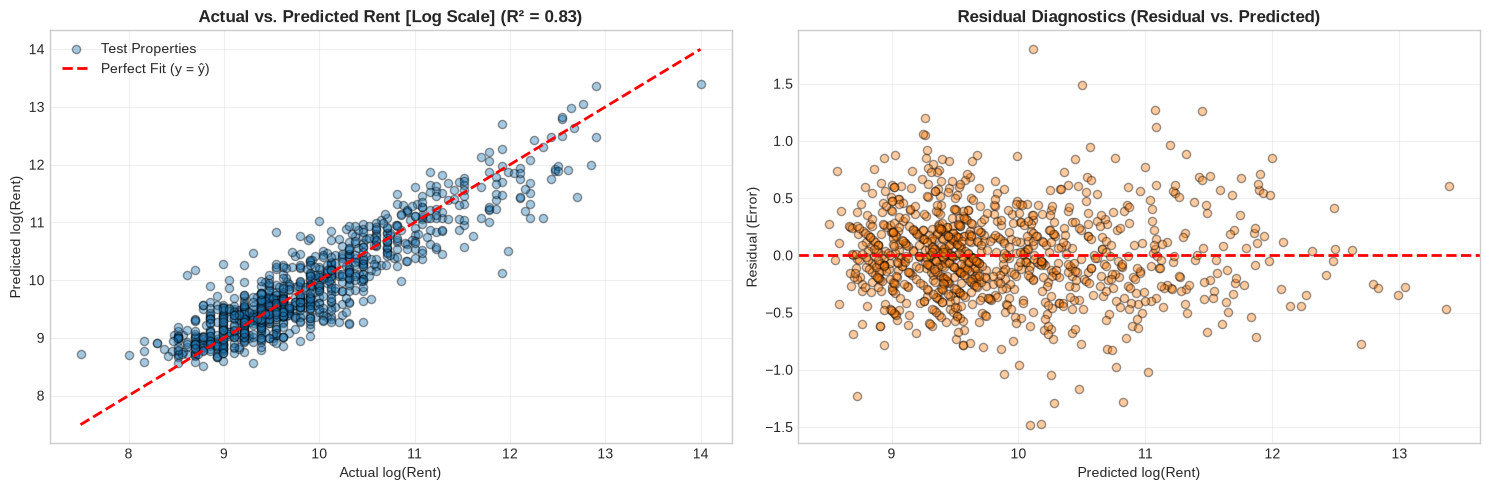

In [12]:
residuals_log = y_log_test - pred_log

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Actual vs Predicted (Log Scale)
axes[0].scatter(y_log_test, pred_log, color="#1f77b4", alpha=0.4, edgecolors="k", s=35, label="Test Properties")
min_val = min(y_log_test.min(), pred_log.min())
max_val = max(y_log_test.max(), pred_log.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=2, label="Perfect Fit (y = ŷ)")
axes[0].set_title(f"Actual vs. Predicted Rent [Log Scale] (R² = {r2_score(y_log_test, pred_log):.2f})", fontweight="bold")
axes[0].set_xlabel("Actual log(Rent)")
axes[0].set_ylabel("Predicted log(Rent)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Residual Diagnostics (Homoscedasticity Check)
axes[1].scatter(pred_log, residuals_log, color="#ff7f0e", alpha=0.4, edgecolors="k", s=35)
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_title("Residual Diagnostics (Residual vs. Predicted)", fontweight="bold")
axes[1].set_xlabel("Predicted log(Rent)")
axes[1].set_ylabel("Residual (Error)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 💡 Step 8: Model Coefficients & Rent Drivers (Feature Importance)

In a log-linear model:
$$\log(\text{Rent}) = \beta_0 + \sum \beta_i X_i$$
Each coefficient $\beta_i$ represents the approximate percentage change in monthly rent per unit change in $X_i$ ($\% \Delta \approx (e^{\beta_i} - 1) \times 100$).

In [13]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient (Beta)": model_log.coef_,
    "Estimated % Impact on Rent": (np.exp(model_log.coef_) - 1) * 100
}).sort_values(by="Coefficient (Beta)", ascending=False).reset_index(drop=True)

print(f"Base Intercept (β₀): {model_log.intercept_:.4f}\n")
print("--- 🏙️ Top Factors That Increase Rent ---")
print(coef_df.head(6).round(2).to_string(index=False))

print("\n--- 📉 Factors That Decrease Rent ---")
print(coef_df.tail(6).round(2).to_string(index=False))

Base Intercept (β₀): 8.6091

--- 🏙️ Top Factors That Increase Rent ---
              Feature  Coefficient (Beta)  Estimated % Impact on Rent
          City_Mumbai                0.94                      156.88
                  BHK                0.23                       25.60
           City_Delhi                0.19                       20.43
             Bathroom                0.15                       15.68
    Furnishing_Status                0.14                       14.54
Area Type_Carpet Area                0.12                       12.96

--- 📉 Factors That Decrease Rent ---
                          Feature  Coefficient (Beta)  Estimated % Impact on Rent
Tenant Preferred_Bachelors/Family               -0.06                       -5.59
          Tenant Preferred_Family               -0.15                      -13.67
                   City_Hyderabad               -0.15                      -14.18
                     City_Kolkata               -0.28                    

### 💼 Key Business Takeaways:
1. **The Mumbai Metropolitan Premium (`City_Mumbai`)**:
   - Having a property located in Mumbai commands an extraordinary **+156.9% rent premium** relative to the baseline metro (Bangalore)!
2. **Structural Scale (`BHK`, `Bathroom`, `Size`)**:
   - Each additional bedroom (`BHK`) adds **~+25.6%** to rent, and each additional bathroom adds **~+15.7%**.
3. **Furnishing Value (`Furnishing_Status`)**:
   - Moving from Unfurnished $\to$ Semi-Furnished $\to$ Fully Furnished adds **~+14.5%** rental yield per level.
4. **Disintermediation Discount (`Point of Contact: Contact Owner`)**:
   - Directly renting from owners is associated with a **~-29.0% lower rent** compared to broker/agent-managed properties.

---
## 🎯 Step 9: Live Rental Valuation Simulator (Appraisal Tool)

We simulate rental valuations for two customer properties:
- **Property 1**: 2 BHK, 1000 sq ft, 2 Bathrooms, 5th Floor, Fully Furnished (2), Carpet Area, Mumbai, Bachelors/Family, Contact Owner.
- **Property 2**: 2 BHK, 1000 sq ft, 2 Bathrooms, Ground Floor (0), Unfurnished (0), Super Area, Kolkata, Bachelors/Family, Contact Owner.

In [14]:
# Define simulation scenarios
sample_properties = pd.DataFrame([
    {
        "description": "2 BHK Furnished Flat in Mumbai (1,000 sqft, 5th Floor, Owner)",
        "BHK": 2, "Size": 1000, "Bathroom": 2, "Floor_Level": 5, "Furnishing_Status": 2,
        "Area Type_Carpet Area": 1, "Area Type_Super Area": 0,
        "City_Chennai": 0, "City_Delhi": 0, "City_Hyderabad": 0, "City_Kolkata": 0, "City_Mumbai": 1,
        "Tenant Preferred_Bachelors/Family": 1, "Tenant Preferred_Family": 0,
        "Point of Contact_Contact Builder": 0, "Point of Contact_Contact Owner": 1
    },
    {
        "description": "2 BHK Unfurnished Flat in Kolkata (1,000 sqft, Ground Floor, Owner)",
        "BHK": 2, "Size": 1000, "Bathroom": 2, "Floor_Level": 0, "Furnishing_Status": 0,
        "Area Type_Carpet Area": 0, "Area Type_Super Area": 1,
        "City_Chennai": 0, "City_Delhi": 0, "City_Hyderabad": 0, "City_Kolkata": 1, "City_Mumbai": 0,
        "Tenant Preferred_Bachelors/Family": 1, "Tenant Preferred_Family": 0,
        "Point of Contact_Contact Builder": 0, "Point of Contact_Contact Owner": 1
    }
])

pred_log_values = model_log.predict(sample_properties[X.columns])
sample_properties["Predicted Monthly Rent"] = np.expm1(pred_log_values)

print("=" * 70)
print(" 🏷️ LIVE REAL ESTATE RENTAL APPRAISALS")
print("=" * 70)
for _, prop in sample_properties.iterrows():
    print(f"Property:    {prop['description']}")
    print(f"Fair Rent:   ₹{prop['Predicted Monthly Rent']:,.0f}/month")
    print("-" * 70)

 🏷️ LIVE REAL ESTATE RENTAL APPRAISALS
Property:    2 BHK Furnished Flat in Mumbai (1,000 sqft, 5th Floor, Owner)
Fair Rent:   ₹47,254/month
----------------------------------------------------------------------
Property:    2 BHK Unfurnished Flat in Kolkata (1,000 sqft, Ground Floor, Owner)
Fair Rent:   ₹9,628/month
----------------------------------------------------------------------


---
## 💾 Step 10: Model Serialization & Production Deployment

In [15]:
# Save trained valuation model package
model_dir = Path("data/house_rent")
model_dir.mkdir(parents=True, exist_ok=True)
model_file = model_dir / "house_rent_model.pkl"

export_package = {
    "model": model_log,
    "feature_columns": list(X.columns)
}

joblib.dump(export_package, model_file)
print(f"✅ Production rental valuation package saved to: {model_file}")

# Smoke test verification
loaded_pkg = joblib.load(model_file)
smoke_pred = np.expm1(loaded_pkg["model"].predict(X_test.iloc[[0]]))
print(f"🧪 Smoke Test Passed: Predicted ₹{smoke_pred[0]:,.0f}/month for test record 0.")

✅ Production rental valuation package saved to: data/house_rent/house_rent_model.pkl
🧪 Smoke Test Passed: Predicted ₹13,615/month for test record 0.
